<a href="https://colab.research.google.com/github/Mubby03/Machine-Deep-Learning-Pancakes/blob/main/Diabetes_standadized_augmented.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This project focuses on predicting diabetes using various machine learning classification algorithms. The dataset used contains several diagnostic measurements and an outcome variable indicating whether the patient has diabetes.

**Key Steps and Methodologies:**

1.  **Data Loading and Initial Exploration:**
    *   The `diabetes.csv` dataset is loaded into a Pandas DataFrame.
    *   Initial inspection revealed '0' values in key features (Glucose, BloodPressure, SkinThickness, Insulin, BMI) which were treated as missing data, as they are physiologically impossible.

2.  **Data Preparation and Imputation:**
    *   **Age Grouping:** A new feature, `AgeGroup`, was created by binning the 'Age' column into 10-year intervals. This allowed for more refined imputation.
    *   **Imputation Strategy:** Missing '0' values in `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, and `BMI` were replaced with `np.nan`.
    *   **Group-wise Imputation:** Missing values were imputed within each `AgeGroup`. `Glucose` and `BloodPressure` were imputed using the mean, while `SkinThickness`, `Insulin`, and `BMI` were imputed using the median to account for potential skewness and outliers.

3.  **Correlation Analysis:**
    *   A Pearson correlation matrix was generated and visualized as a heatmap.
    *   No single feature showed a very high correlation (0.7 or above) with the 'Outcome', indicating that diabetes is likely influenced by a combination of factors.
    *   No strong multicollinearity was observed between features, suggesting that all features could be potentially useful for modeling.

4.  **Data Augmentation and Scaling:**
    *   **Feature and Target Split:** The dataset was split into features (`X`) and the target variable (`y`). The `AgeGroup` column was dropped from `X` as it was primarily for imputation.
    *   **Train-Test Split:** The data was split into training (70%) and testing (30%) sets using `train_test_split`, ensuring stratification to maintain class proportions.
    *   **SMOTE for Imbalance:** Synthetic Minority Over-sampling Technique (SMOTE) was applied to the training data to address class imbalance in the 'Outcome' variable, creating a balanced dataset for model training.
    *   **Feature Scaling:** `StandardScaler` was used to standardize the features in both the SMOTE-resampled training data and the untouched test data.

5.  **Model Training and Evaluation:**
    *   Six different classification models were trained and evaluated:
        *   Logistic Regression
        *   Support Vector Machine (SVM)
        *   Decision Tree
        *   K-Nearest Neighbors (KNN)
        *   Random Forest
        *   Gradient Boosting
    *   Each model's performance was assessed using Accuracy, F1-score (weighted), and a detailed Classification Report and Confusion Matrix.

6.  **Model Comparison:**
    *   A comparative analysis of all models based on their F1-scores (weighted) on the test set was performed.
    *   **Random Forest** emerged as the best-performing model, achieving the highest F1-score and accuracy among all evaluated algorithms.

This project provides a comprehensive workflow for building and evaluating predictive models for diabetes, from robust data preprocessing to comparative model analysis.

In [ ]:
print("excercise diabetes")

excercise diabetes


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from collections import Counter
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import f1_score
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler


In [ ]:
diabetes = pd.read_csv('/content/drive/MyDrive/diabetes.csv')
diabetes.iloc[5:11]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1
10,4,110,92,0,0,37.6,0.191,30,0


**Data Preparation: Handling Hidden Nulls**
  
While our initial check showed no nulls, we discovered "0" values that clearly represent missing data. To fill these gaps, I’ll use an average measurement, though I could refine this later by a
veraging specific sub-groups like age. My choice between using the mean or median will depend on each variable’s distribution, skewness, and the presence of outliers.

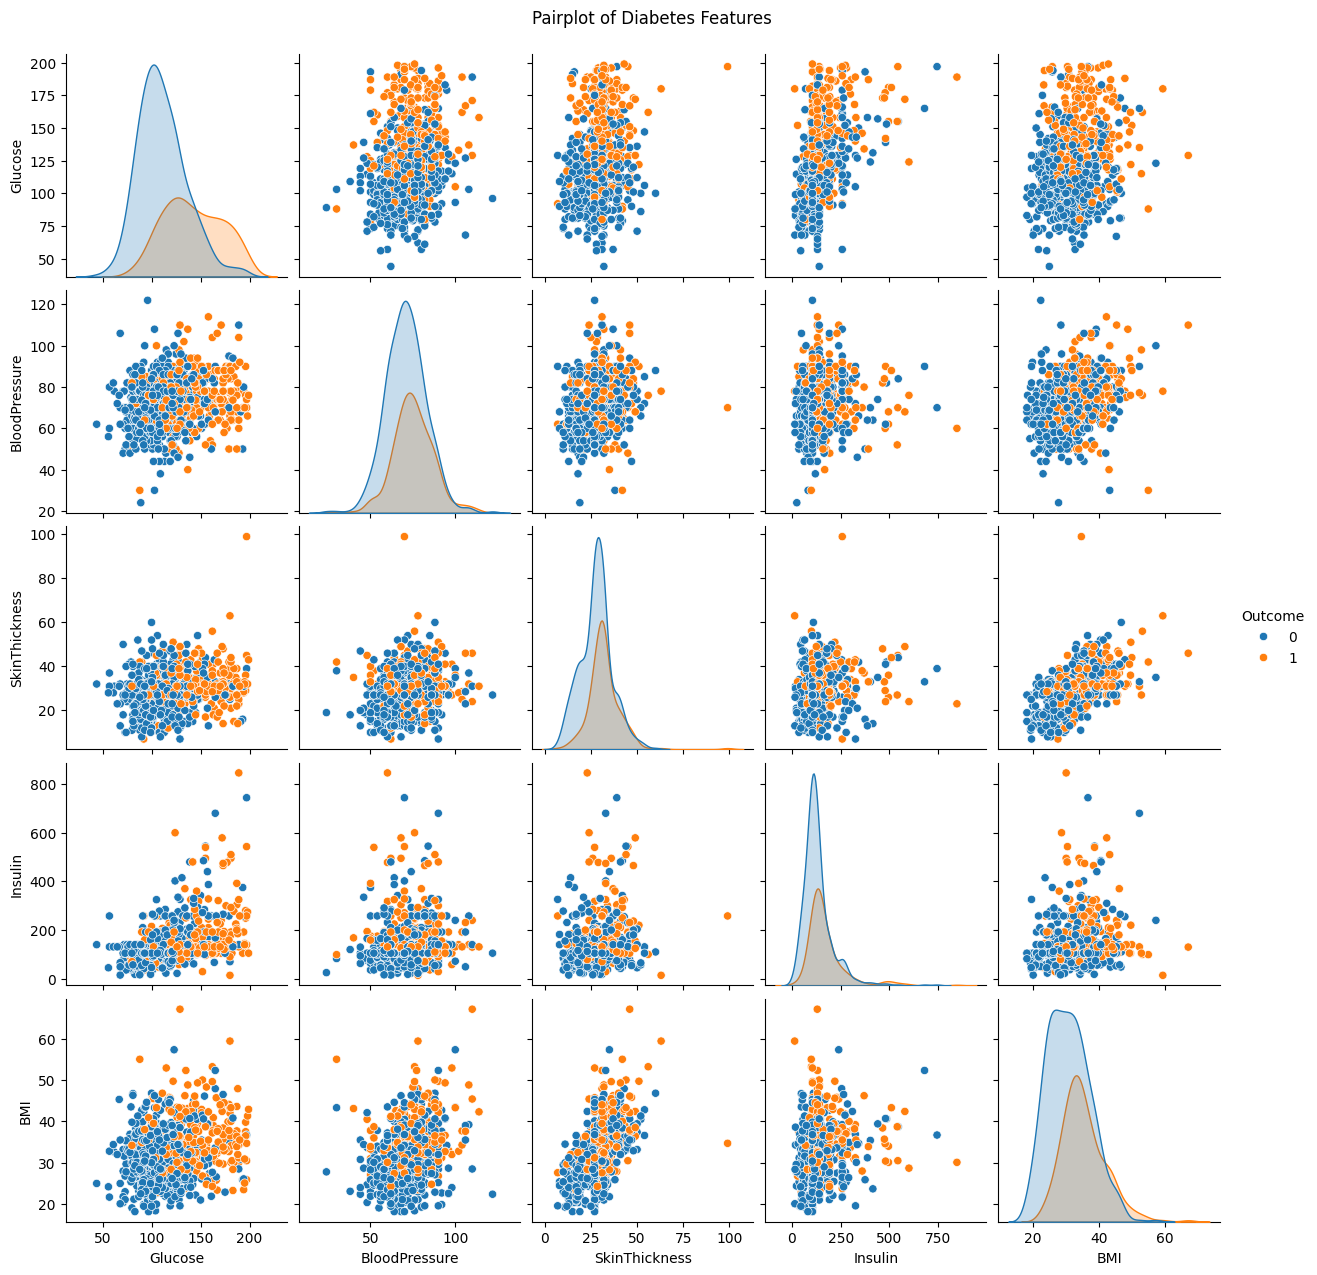

In [ ]:
# Define the columns you want to include in the pairplot
columns_for_pairplot = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'Outcome']

# Create a pairplot
sns.pairplot(diabetes[columns_for_pairplot], hue='Outcome', diag_kind='kde')
plt.suptitle('Pairplot of Diabetes Features', y=1.02) # Add a title above the plots
plt.show()

This pairplot will show scatter plots for all combinations of the selected features, allowing us to see potential relationships. The `hue='Outcome'` argument will color the points based on the 'Outcome' variable (whether the patient has diabetes or not), which can help identify patterns related to the target variable. The `diag_kind='kde'` displays kernel density estimates on the diagonal, showing the distribution of each variable.

In [ ]:
cols_with_missing = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

diabetes[cols_with_missing] = diabetes[cols_with_missing].replace(0, np.nan)
#create age bracket
bins = list(range(0, 101, 10))  # 0,10,20,...100
labels = [f'{i}-{i+9}' for i in range(0, 90, 10)] + ['90+']

diabetes['AgeGroup'] = pd.cut(
    diabetes['Age'],
    bins=bins,
    labels=labels,
    right=False
)

mean_cols = ['Glucose', 'BloodPressure']
median_cols = ['SkinThickness', 'Insulin', 'BMI']

In [ ]:
for age_group, group_data in diabetes.groupby('AgeGroup'):

    if group_data.empty:
        continue

    # Impute mean_cols individually
    for col in mean_cols:
        # Only impute if there are non-null values in the current group and column
        if not group_data[col].isnull().all():
            imputer = SimpleImputer(strategy='mean')
            # fit_transform returns a 2D array, so .ravel() converts it to 1D for proper assignment
            diabetes.loc[group_data.index, col] = imputer.fit_transform(group_data[[col]]).ravel()

    # Impute median_cols individually
    for col in median_cols:
        # Only impute if there are non-null values in the current group and column
        if not group_data[col].isnull().all():
            imputer = SimpleImputer(strategy='median')
            # fit_transform returns a 2D array, so .ravel() converts it to 1D for proper assignment
            diabetes.loc[group_data.index, col] = imputer.fit_transform(group_data[[col]]).ravel()

/tmp/ipython-input-431/310092274.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for age_group, group_data in diabetes.groupby('AgeGroup'):


In [ ]:
from sklearn.impute import SimpleImputer

mean_cols = ['Glucose', 'BloodPressure']
median_cols = ['SkinThickness', 'Insulin', 'BMI']

mean_imputer = SimpleImputer(strategy='mean')
median_imputer = SimpleImputer(strategy='median')

diabetes[mean_cols] = mean_imputer.fit_transform(diabetes[mean_cols])
diabetes[median_cols] = median_imputer.fit_transform(diabetes[median_cols])

In [ ]:
diabetes.head(5)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,AgeGroup
5,5,116.0,74.000000,32.0,140.0,25.60,0.201,30,0,30-39
6,3,78.0,50.000000,32.0,88.0,31.00,0.248,26,1,20-29
7,10,115.0,68.824468,27.0,105.0,35.30,0.134,29,0,20-29
8,2,197.0,70.000000,45.0,543.0,30.50,0.158,53,1,50-59
9,8,125.0,96.000000,28.5,192.0,33.05,0.232,54,1,50-59
10,4,110.0,92.000000,32.0,140.0,37.60,0.191,30,0,30-39


In [ ]:
diabetes.iloc[5:11]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,AgeGroup
5,5,116.0,74.000000,32.0,140.0,25.60,0.201,30,0,30-39
6,3,78.0,50.000000,32.0,88.0,31.00,0.248,26,1,20-29
7,10,115.0,68.824468,27.0,105.0,35.30,0.134,29,0,20-29
8,2,197.0,70.000000,45.0,543.0,30.50,0.158,53,1,50-59
9,8,125.0,96.000000,28.5,192.0,33.05,0.232,54,1,50-59
10,4,110.0,92.000000,32.0,140.0,37.60,0.191,30,0,30-39


Observing the method used in preparing the data, a new feature, AgeGroup, was introduced to better capture age-related patterns in the dataset. Zero values in Glucose, BloodPressure, SkinThickness, Insulin, BMI, and DiabetesPedigreeFunction were treated as missing and imputed using either the mean or median, depending on the underlying distribution of each feature. Features with noticeable skewness or the presence of outliers were imputed using the median to reduce the influence of extreme values, while features with more symmetric distributions were imputed using the mean.

Furthermore, instead of performing imputation across the entire dataset, the AgeGroup feature was used to constrain the imputation process within specific age brackets (in 10-year intervals). This ensured that missing values were estimated using statistics derived only from individuals within the same age range. By doing so, the imputation process preserved age-dependent physiological relationships and reduced the risk of introducing bias from unrelated age groups.

<Axes: >

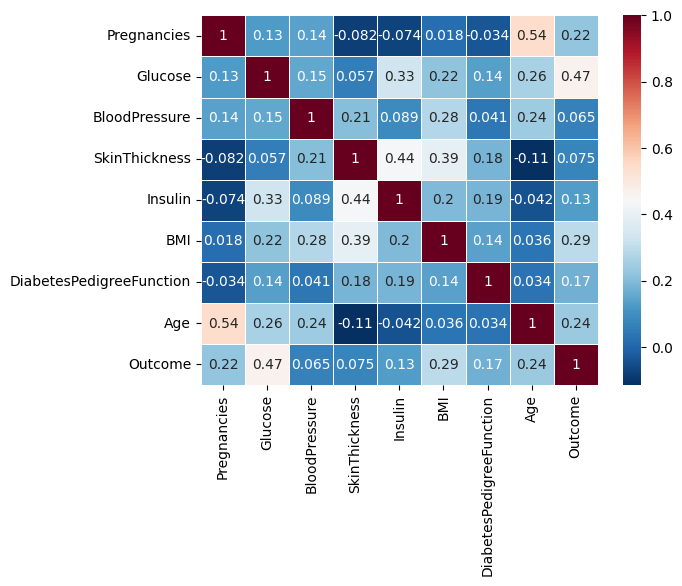

In [ ]:
pearsoncorr=diabetes.corr(method='pearson',numeric_only=True)
import seaborn as sb
sb.heatmap(pearsoncorr,
            xticklabels=pearsoncorr.columns,
            yticklabels=pearsoncorr.columns,
            cmap='RdBu_r',
            annot=True,
            linewidth=0.5)

I can get many useful insights from this Pearson correlation matrix, but I will focus on the relationship between the Outcome and the eight other features.

From the matrix, none of the features has a correlation of 0.7 or higher with the Outcome. This means no single feature strongly determines whether a person has diabetes.

Also, no features are highly correlated with each other, so there is no serious multicollinearity problem.

Because of this, we will not drop any feature based only on correlation. Even features with low correlation may still help the model when combined with others.

So for now, we will keep all the features and let the model decide which ones are most important.

In [ ]:
X = diabetes.drop('Outcome', axis=1)
print('The values of the inputs are :',X)
y = diabetes['Outcome']
print('The values of target are :',y)

The values of the inputs are :      Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0              6      148             72             35        0  33.6   
1              1       85             66             29        0  26.6   
2              8      183             64              0        0  23.3   
3              1       89             66             23       94  28.1   
4              0      137             40             35      168  43.1   
..           ...      ...            ...            ...      ...   ...   
763           10      101             76             48      180  32.9   
764            2      122             70             27        0  36.8   
765            5      121             72             23      112  26.2   
766            1      126             60              0        0  30.1   
767            1       93             70             31        0  30.4   

     DiabetesPedigreeFunction  Age  
0                       0.627   50  
1     

**DATA AUGMENTATION**

In [ ]:
from imblearn.over_sampling import SMOTE

In [ ]:
diabetes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


We separate the dataset into features (`X`) and the target variable (`y`). The `AgeGroup` column is dropped from features as it was primarily created for the imputation process.

In [ ]:
# Split data into training and testing sets
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print('X_train Shape:', X_train.shape)
print('X_test Shape:', X_test.shape)
print('Y_train Shape:', Y_train.shape)
print('Y_test Shape:', Y_test.shape)

print('\nClass distribution in Y_train before SMOTE:\n', Y_train.value_counts())

X_train Shape: (537, 8)
X_test Shape: (231, 8)
Y_train Shape: (537,)
Y_test Shape: (231,)

Class distribution in Y_train before SMOTE:
 Outcome
0    349
1    188
Name: count, dtype: int64


The data is split into training and testing sets. `stratify=y` ensures that the proportion of 'Outcome' classes is maintained in both the training and testing sets, which is important for imbalanced datasets.

In [ ]:
# Apply SMOTE only on training data
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, Y_train)

print("Before SMOTE:", Y_train.value_counts())
print("After SMOTE:", pd.Series(y_train_sm).value_counts())

Before SMOTE: Outcome
0    349
1    188
Name: count, dtype: int64
After SMOTE: Outcome
0    349
1    349
Name: count, dtype: int64


In [ ]:
scaler = StandardScaler()

# Fit scaler on SMOTE-resampled training data
X_train_scaled = scaler.fit_transform(X_train_sm)

# Apply same scaler to untouched test data
X_test_scaled = scaler.transform(X_test)

Linear Regression

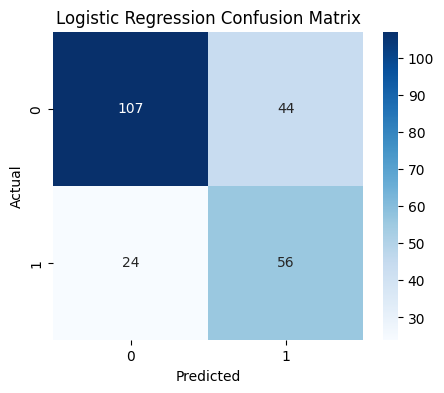

              precision    recall  f1-score   support

           0       0.82      0.71      0.76       151
           1       0.56      0.70      0.62        80

    accuracy                           0.71       231
   macro avg       0.69      0.70      0.69       231
weighted avg       0.73      0.71      0.71       231

Accuracy: 0.7056277056277056
F1 Score (weighted): 0.7115429881387328


In [ ]:
# Train Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train_sm)  # Use scaled & SMOTE-resampled training data

# Make predictions
y_lr_pred = lr.predict(X_test_scaled)

# Confusion Matrix
cm = confusion_matrix(Y_test, y_lr_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Logistic Regression Confusion Matrix')
plt.show()

# Metrics
print(classification_report(Y_test, y_lr_pred))
print("Accuracy:", accuracy_score(Y_test, y_lr_pred))
F1_LR = f1_score(Y_test, y_lr_pred, average='weighted')
print("F1 Score (weighted):", F1_LR)

**SVM**

SVM Accuracy: 0.714
SVM F1 (weighted): 0.720

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.72      0.77       151
           1       0.57      0.71      0.63        80

    accuracy                           0.71       231
   macro avg       0.70      0.71      0.70       231
weighted avg       0.74      0.71      0.72       231



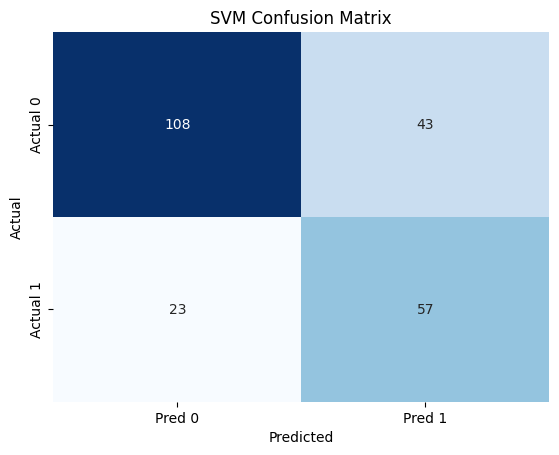

In [ ]:
# Train SVM
svm = SVC(random_state=42)
svm.fit(X_train_scaled, y_train_sm)

# Predictions
y_pred_svm = svm.predict(X_test_scaled)

# Metrics
acc = accuracy_score(Y_test, y_pred_svm)
f1 = f1_score(Y_test, y_pred_svm, average="weighted")
print(f"SVM Accuracy: {acc:.3f}")
print(f"SVM F1 (weighted): {f1:.3f}")
print("\nClassification Report:\n", classification_report(Y_test, y_pred_svm))

# Confusion Matrix Heatmap
cm = confusion_matrix(Y_test, y_pred_svm)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Pred 0','Pred 1'],
            yticklabels=['Actual 0','Actual 1'])
plt.title('SVM Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

**Decision Tree**

Decision Tree Accuracy: 0.675
Decision Tree F1 (weighted): 0.681

Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.70      0.74       151
           1       0.53      0.64      0.58        80

    accuracy                           0.68       231
   macro avg       0.65      0.67      0.66       231
weighted avg       0.69      0.68      0.68       231



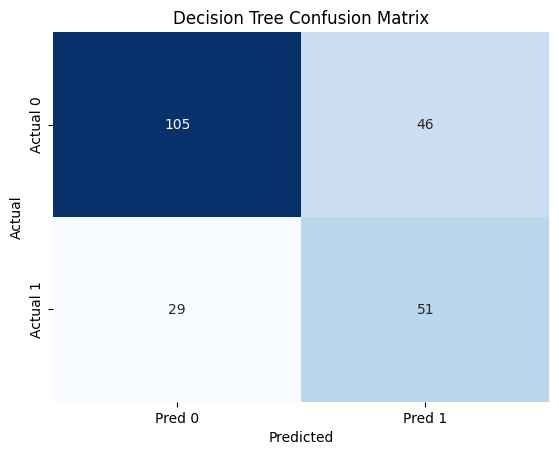

In [ ]:
# Train Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_scaled, y_train_sm)

# Predictions
y_pred_dt = dt.predict(X_test_scaled)

# Metrics
acc = accuracy_score(Y_test, y_pred_dt)
f1 = f1_score(Y_test, y_pred_dt, average="weighted")
print(f"Decision Tree Accuracy: {acc:.3f}")
print(f"Decision Tree F1 (weighted): {f1:.3f}")
print("\nClassification Report:\n", classification_report(Y_test, y_pred_dt))

# Confusion Matrix Heatmap
cm = confusion_matrix(Y_test, y_pred_dt)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Pred 0','Pred 1'],
            yticklabels=['Actual 0','Actual 1'])
plt.title('Decision Tree Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

**KNN**

KNN Accuracy: 0.710
KNN F1 (weighted): 0.716

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.71      0.76       151
           1       0.56      0.71      0.63        80

    accuracy                           0.71       231
   macro avg       0.69      0.71      0.70       231
weighted avg       0.73      0.71      0.72       231



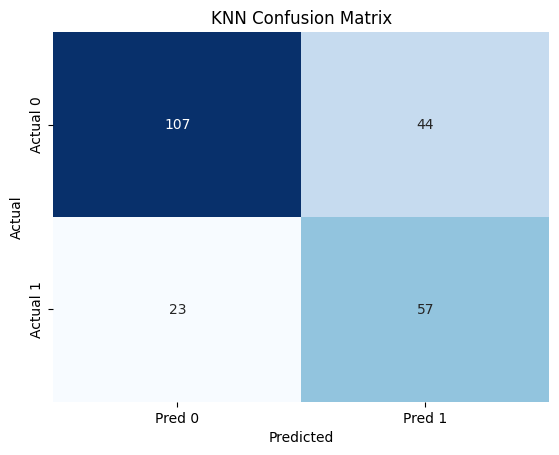

In [ ]:
# Train KNN
knn = KNeighborsClassifier()
knn.fit(X_train_scaled, y_train_sm)

# Predictions
y_pred_knn = knn.predict(X_test_scaled)

# Metrics
acc = accuracy_score(Y_test, y_pred_knn)
f1 = f1_score(Y_test, y_pred_knn, average="weighted")
print(f"KNN Accuracy: {acc:.3f}")
print(f"KNN F1 (weighted): {f1:.3f}")
print("\nClassification Report:\n", classification_report(Y_test, y_pred_knn))

# Confusion Matrix Heatmap
cm = confusion_matrix(Y_test, y_pred_knn)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Pred 0','Pred 1'],
            yticklabels=['Actual 0','Actual 1'])
plt.title('KNN Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

**Random Forest**

Random Forest Accuracy: 0.749
Random Forest F1 (weighted): 0.753

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.75      0.80       151
           1       0.61      0.74      0.67        80

    accuracy                           0.75       231
   macro avg       0.73      0.75      0.73       231
weighted avg       0.76      0.75      0.75       231



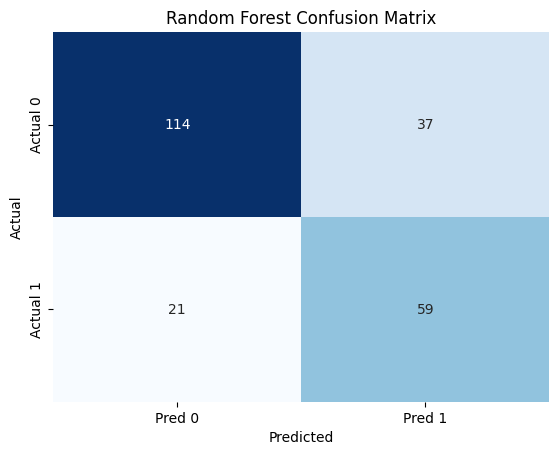

In [ ]:
# Train Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_scaled, y_train_sm)

# Predictions
y_pred_rf = rf.predict(X_test_scaled)

# Metrics
acc = accuracy_score(Y_test, y_pred_rf)
f1 = f1_score(Y_test, y_pred_rf, average="weighted")
print(f"Random Forest Accuracy: {acc:.3f}")
print(f"Random Forest F1 (weighted): {f1:.3f}")
print("\nClassification Report:\n", classification_report(Y_test, y_pred_rf))

# Confusion Matrix Heatmap
cm = confusion_matrix(Y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Pred 0','Pred 1'],
            yticklabels=['Actual 0','Actual 1'])
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

**Gradient Boosting**

Gradient Boosting Accuracy: 0.723
Gradient Boosting F1 (weighted): 0.727

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.74      0.78       151
           1       0.59      0.69      0.63        80

    accuracy                           0.72       231
   macro avg       0.70      0.71      0.70       231
weighted avg       0.74      0.72      0.73       231



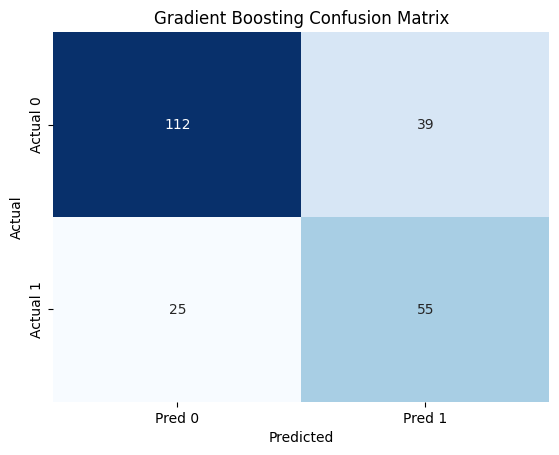

In [ ]:
# Train Gradient Boosting
gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train_scaled, y_train_sm)

# Predictions
y_pred_gb = gb.predict(X_test_scaled)

# Metrics
acc = accuracy_score(Y_test, y_pred_gb)
f1 = f1_score(Y_test, y_pred_gb, average="weighted")
print(f"Gradient Boosting Accuracy: {acc:.3f}")
print(f"Gradient Boosting F1 (weighted): {f1:.3f}")
print("\nClassification Report:\n", classification_report(Y_test, y_pred_gb))

# Confusion Matrix Heatmap
cm = confusion_matrix(Y_test, y_pred_gb)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Pred 0','Pred 1'],
            yticklabels=['Actual 0','Actual 1'])
plt.title('Gradient Boosting Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

**Model Comparison**

                 Model  Accuracy  F1 (weighted)
4        Random Forest  0.748918       0.753307
5    Gradient Boosting  0.722944       0.727356
1                  SVM  0.714286       0.720027
3                  KNN  0.709957       0.715945
0  Logistic Regression  0.705628       0.711543
2        Decision Tree  0.675325       0.681233


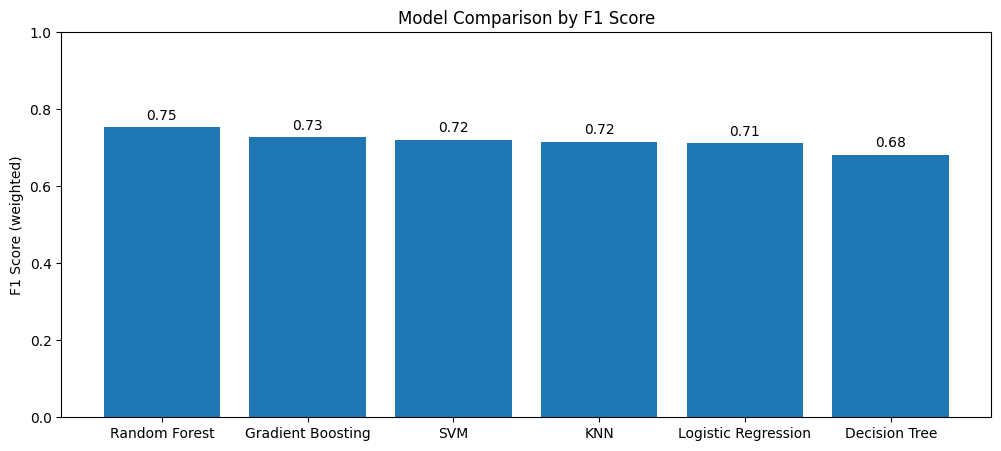

In [ ]:
# Use the ACTUAL trained models
models = {
    "Logistic Regression": lr,
    "SVM": svm,
    "Decision Tree": dt,
    "KNN": knn,
    "Random Forest": rf,
    "Gradient Boosting": gb
}

results = []

for name, model in models.items():
    y_pred = model.predict(X_test_scaled)
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(Y_test, y_pred),
        "F1 (weighted)": f1_score(Y_test, y_pred, average="weighted")
    })

df_results = pd.DataFrame(results).sort_values(by="F1 (weighted)", ascending=False)
print(df_results)

# Plot F1 scores
plt.figure(figsize=(12,5))
plt.bar(df_results["Model"], df_results["F1 (weighted)"])
plt.ylim(0, 1)
plt.ylabel("F1 Score (weighted)")
plt.title("Model Comparison by F1 Score")

for i, v in enumerate(df_results["F1 (weighted)"]):
    plt.text(i, v + 0.02, f"{v:.2f}", ha="center")

plt.show()